# ¡Hola Karen! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Hola Karen, ¿cómo va todo? Espero que estés teniendo una buena jornada.

Buen trabajo completando todos los puntos del notebook. El proyecto en general está bien logrado, con una correcta implementación del código necesario. Solo falta pulir algunos detalles y sumar algunos gráficos para complementar tu análisis. Te dejé anotaciones en rojo con observaciones puntuales para que puedas hacer esos ajustes.

Ante cualquier duda, no dudes en dejar un comentario en azul. Con gusto lo atenderé en la próxima iteración.

Saludos!


</div>

## Resumen de la revisión v2 <a class="tocSkip"></a>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v2 </b> <a class="tocSkip"></a>

Bien hecho Karen, buen trabajo con las últimas correcciones. Has terminado completamente las tareas necesarias del notebook, no tengo comentarios de corrección adicionales, tu proyecto está aprobado. Los conocimientos que aplicaste aquí te serán muy útiles para análisis futuros, mucho éxito!

Saludos!

</div>

----

In [79]:
#importar librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as st


In [80]:
#cargar dataset
games=pd.read_csv('games.csv')

In [81]:
#info del dataset
games.info()
games.head()
games.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

In [82]:
#nombre de columnas a minusculas
games.columns = games.columns.str.lower()
print(games.columns)

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


In [83]:
# Para year_of_release (maneja valores problemáticos)
games['year_of_release'] = pd.to_numeric(games['year_of_release'], errors='coerce').astype('Int64')

# Para user_score (maneja valores problemáticos)
games['user_score'] = pd.to_numeric(games['user_score'], errors='coerce')
games.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  Int64  
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       7590 non-null   float64
 10  rating           9949 non-null   object 
dtypes: Int64(1), float64(6), object(4)
memory usage: 1.4+ MB


In [84]:
#Se cambio el tipo de datos de year_of_release a entero para mejorar su estructura y user_score de objeto a flotante ya  que observamos que esta calificacion esta dada en flotante, se paso los valores ausentes a nan para poder tranajar con ellos

<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Bien hecho con la gestión de los valores ausentes. En los casos donde hay demasiados en una columna, me parece bien dejar los nulos tal como están o reemplazarlos por algún valor identificable. En este caso, para critic_score y user_score, no hay data suficiente para hacer una imputación adecuada y en caso de rellenar con la media o mediana, se introduce un sesgo muy fuerte en la data, por lo que no es adecuado.



</div>

In [85]:
# Calcular las ventas totales sumando todas las regiones
games['total_sales'] = games['na_sales'] + games['eu_sales'] + games['jp_sales'] + games['other_sales']

# Verificar que se creó correctamente
print("Columna 'total_sales'")
print(f"Número de registros: {len(games)}")
print("\nPrimeros 5 registros con ventas totales:")
print(games[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head())

Columna 'total_sales'
Número de registros: 16715

Primeros 5 registros con ventas totales:
                       name  na_sales  eu_sales  jp_sales  other_sales  \
0                Wii Sports     41.36     28.96      3.77         8.45   
1         Super Mario Bros.     29.08      3.58      6.81         0.77   
2            Mario Kart Wii     15.68     12.76      3.79         3.29   
3         Wii Sports Resort     15.61     10.93      3.28         2.95   
4  Pokemon Red/Pokemon Blue     11.27      8.89     10.22         1.00   

   total_sales  
0        82.54  
1        40.24  
2        35.52  
3        32.77  
4        31.38  


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien, también podrías haber usado

```python
    df[['na_sales','jp_sales','eu_sales','other_sales']].sum(axis=1)
```
</div>

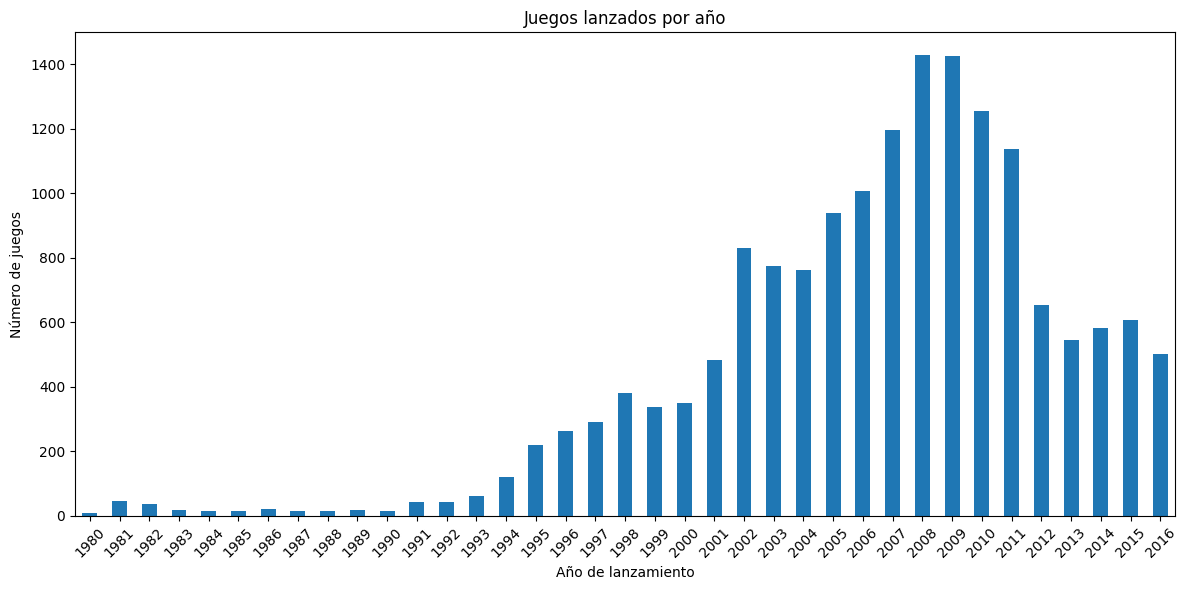

In [86]:
#Grafica juegos lanzados por año
games['year_of_release'].value_counts().sort_index().plot(kind='bar', figsize=(12,6))
plt.title('Juegos lanzados por año')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Número de juegos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     </b> <a class="tocSkip"></a>

Bien, correcto. El gráfico es claro, hubo un peak a fines de los 2000 y luego ha caido a niveles similares a los de inicios del 2000.

</div>

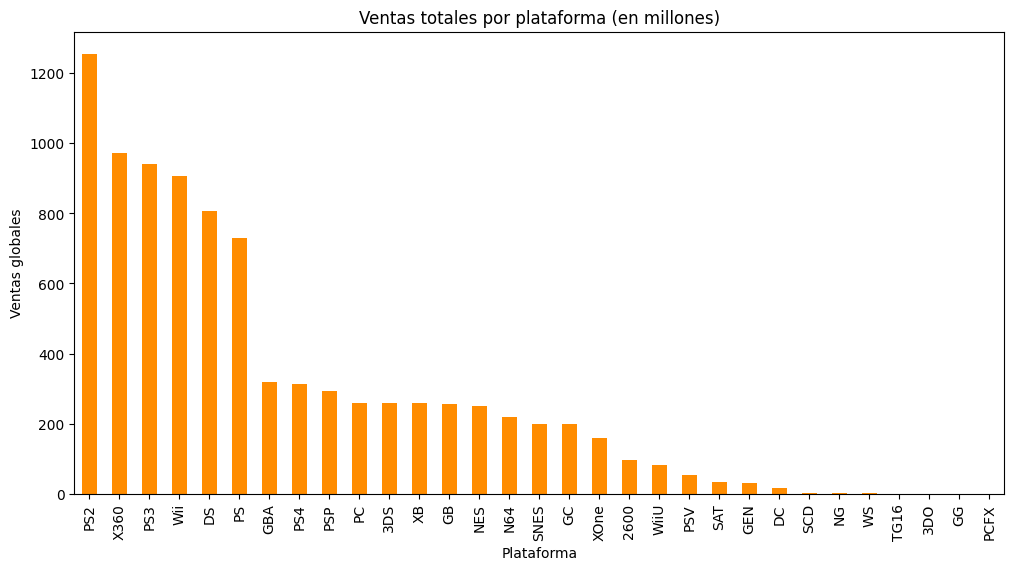

In [87]:
# Ventas totales por plataforma
platform_sales = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
platform_sales.plot(kind='bar', color='darkorange')
plt.title('Ventas totales por plataforma (en millones)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas globales')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con el gráfico, dado que las barras están ordenadas, se puede apreciar claramente las plataformas más exitosas

</div>

=== ANÁLISIS DE PLATAFORMAS ===

Top 15 plataformas con mayores ventas totales:
platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64


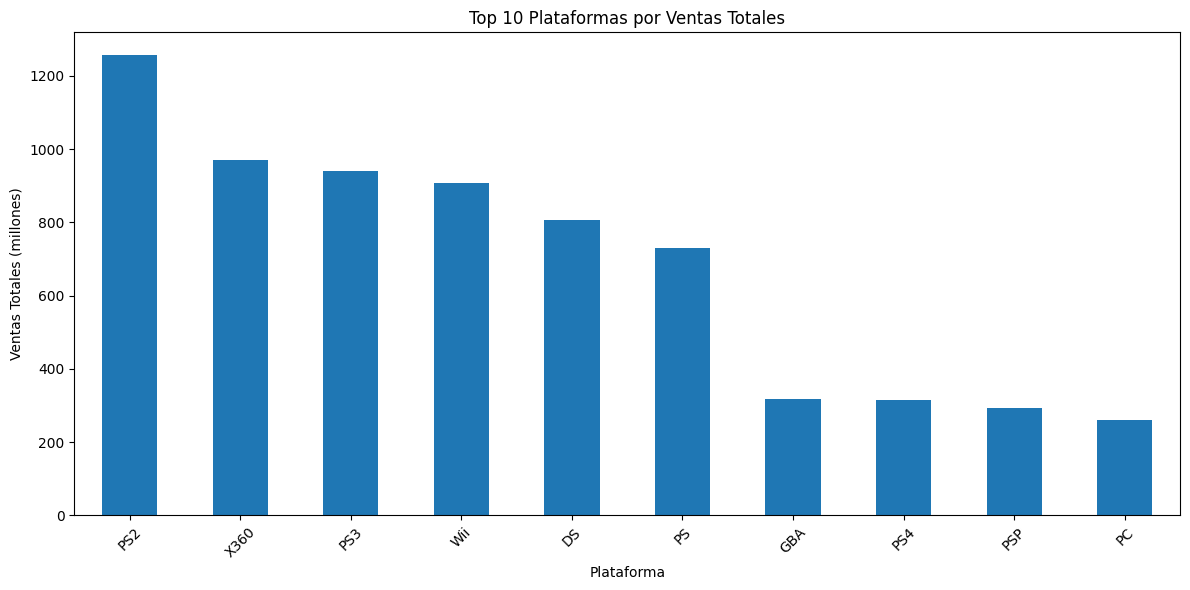

In [88]:
# Analizar ventas totales por plataforma
print("=== ANÁLISIS DE PLATAFORMAS ===")
print()

# Ventas totales por plataforma
ventas_por_plataforma = games.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("Top 15 plataformas con mayores ventas totales:")
print(ventas_por_plataforma.head(10))

# Visualizar las top 10
plt.figure(figsize=(12, 6))
ventas_por_plataforma.head(10).plot(kind='bar')
plt.title('Top 10 Plataformas por Ventas Totales')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

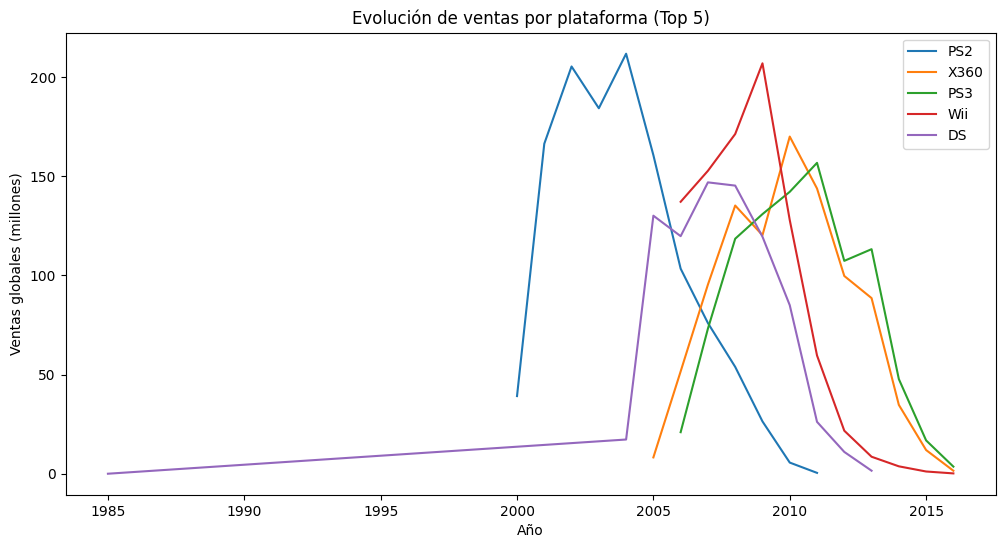

In [89]:
# Top 5 plataformas con mayores ventas
top_platforms = platform_sales.head(5).index
top_data = games[games['platform'].isin(top_platforms)]

plt.figure(figsize=(12,6))
for p in top_platforms:
    subset = top_data[top_data['platform']==p]
    subset.groupby('year_of_release')['total_sales'].sum().plot(label=p)
plt.title('Evolución de ventas por plataforma (Top 5)')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones)')
plt.legend()
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy buen gráfico, permite apreciar el periodo de vida de cada consola, incluyendo su auge y luego caída.

</div>

<Figure size 1200x600 with 0 Axes>

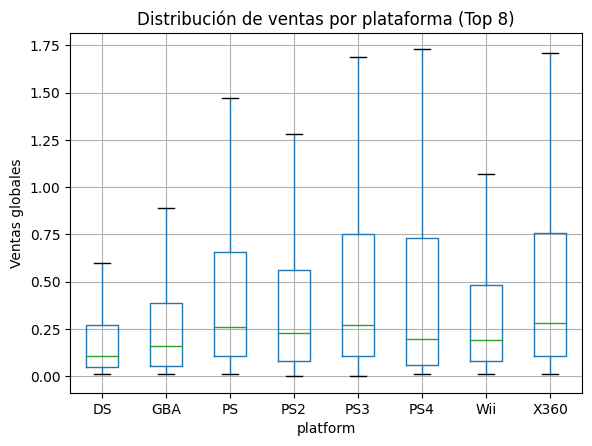

In [90]:
# Boxplot de ventas globales por plataforma
top8_platforms = platform_sales.head(8).index
plt.figure(figsize=(12,6))
games[games['platform'].isin(top8_platforms)].boxplot(column='total_sales', by='platform', showfliers=False)
plt.title('Distribución de ventas por plataforma (Top 8)')
plt.suptitle('')
plt.ylabel('Ventas globales')
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>


Bien hecho, correcto el gráfico. Se puede apreciar la variabilidad de ventas de cada consola gracias a que no estás mostrando los puntos que indican los outliers. Otra opción es usar una escala logarítmica.

</div>

Plataforma elegida: PS2
Tamaño muestra: 1241


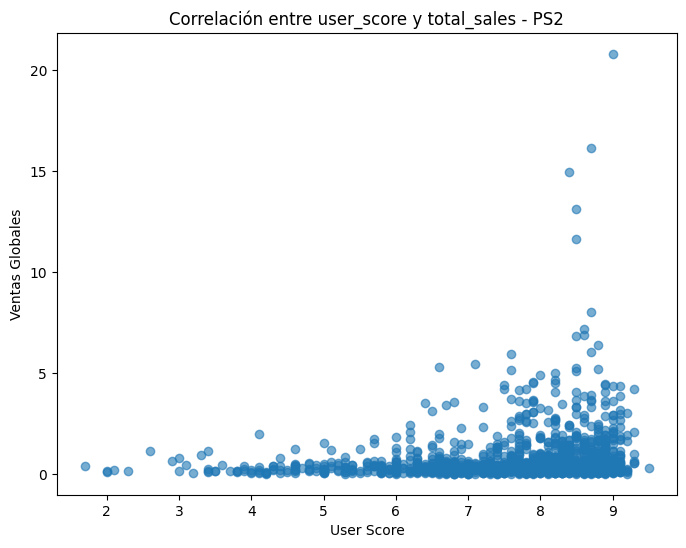

Correlación de Pearson: 0.17286551112058227


In [91]:

popular_platform = games['platform'].value_counts().index[0]
platform_data = games[games['platform']==popular_platform]
corr_data = platform_data[['user_score','total_sales']].dropna()

print("Plataforma elegida:", popular_platform)
print("Tamaño muestra:", len(corr_data))

plt.figure(figsize=(8,6))
plt.scatter(corr_data['user_score'], corr_data['total_sales'], alpha=0.6)
plt.title(f'Correlación entre user_score y total_sales - {popular_platform}')
plt.xlabel('User Score')
plt.ylabel('Ventas Globales')
plt.show()

corr = corr_data['user_score'].corr(corr_data['total_sales'])
print("Correlación de Pearson:", corr)



Plataforma elegida: PS2
Tamaño muestra: 1298


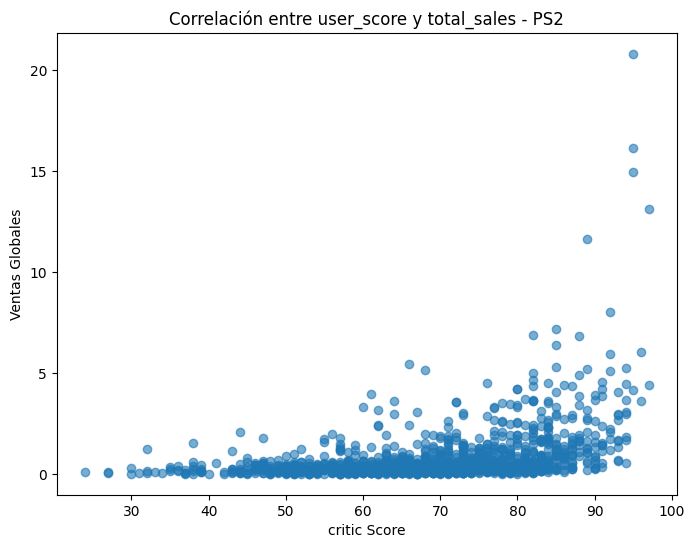

Correlación de Pearson: 0.39543454945454876


In [92]:
opular_platform = games['platform'].value_counts().index[0]
platform_data = games[games['platform']==popular_platform]
corr_data = platform_data[['critic_score','total_sales']].dropna()

print("Plataforma elegida:", popular_platform)
print("Tamaño muestra:", len(corr_data))

plt.figure(figsize=(8,6))
plt.scatter(corr_data['critic_score'], corr_data['total_sales'], alpha=0.6)
plt.title(f'Correlación entre user_score y total_sales - {popular_platform}')
plt.xlabel('critic Score')
plt.ylabel('Ventas Globales')
plt.show()

corr = corr_data['critic_score'].corr(corr_data['total_sales'])
print("Correlación de Pearson:", corr)


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el gráfico y el cálculo del coeficiente. Permite obtener una visión general de la correlación entre ambas variables.

</div>

In [93]:
#Las reseñas de los criticos tiene mas correlacion con las ventas pero aun asi no es una correlación fuerte

In [94]:
# filtra juegos que estén en múltiples plataformas
pivot_table = games.pivot_table(
    index='name',           # Juegos en filas
    columns='platform',     # Plataformas en columnas
    values='total_sales',   # Ventas totales como valores
    aggfunc='sum',          # Suma las ventas
    fill_value=0            # Rellena con 0 donde no hay datos
)

In [95]:

# Calcular ventas totales por juego (suma de todas las plataformas)
pivot_table['total_por_juego'] = pivot_table.sum(axis=1)

# Ordenar por ventas totales descendente y mostrar los top
pivot_table_ordenado = pivot_table.sort_values('total_por_juego', ascending=False)
pivot_table_ordenado.head(10)


platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne,total_por_juego
name,,,,,,,,,,,,,,,,,,,,,
Wii Sports,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,82.54,0.0,0.00,0.0,0.00,82.54
Grand Theft Auto V,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,16.27,0.0,5.47,56.58
Super Mario Bros.,0.0,0.0,0.0,0.0,0.00,5.07,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,45.31
Tetris,0.0,0.0,0.0,0.0,0.00,30.26,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,35.84
Mario Kart Wii,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,35.52,0.0,0.00,0.0,0.00,35.52
Wii Sports Resort,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,32.77,0.0,0.00,0.0,0.00,32.77
Pokemon Red/Pokemon Blue,0.0,0.0,0.0,0.0,0.00,31.38,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.00,31.38
Call of Duty: Black Ops,0.0,0.0,0.0,0.0,0.58,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.37,0.0,14.62,0.0,0.00,30.82
Call of Duty: Modern Warfare 3,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.83,0.0,14.73,0.0,0.00,30.60


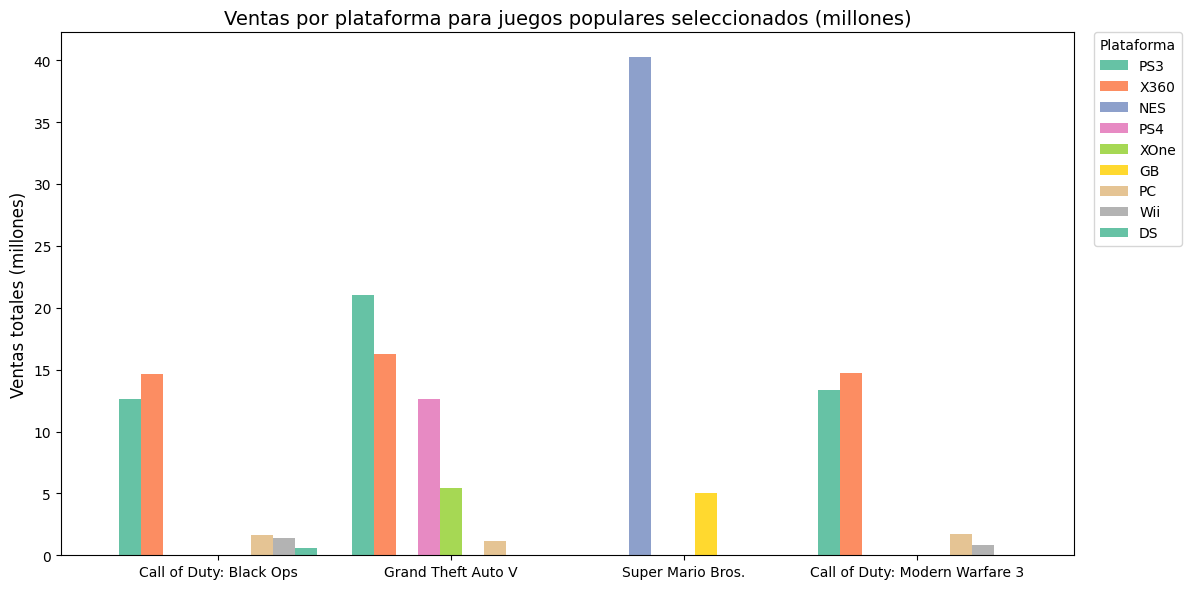

In [106]:
# Filtra columnas con ventas > 0 para los juegos seleccionados
selected_games = pivot_table.loc[
    ["Call of Duty: Black Ops", "Grand Theft Auto V", "Super Mario Bros.","Call of Duty: Modern Warfare 3"]
]

# Mantén solo plataformas con ventas para al menos uno de los juegos
nonzero_cols = selected_games.columns[(selected_games > 0).any(axis=0)]

# AGREGAR ESTA LÍNEA para excluir 'total_por_juego'
nonzero_cols = nonzero_cols.drop('total_por_juego', errors='ignore')

plot_df = selected_games[nonzero_cols]

# Ordena plataformas por ventas totales sumadas de los juegos seleccionados
platform_order = plot_df.sum(axis=0).sort_values(ascending=False).index
plot_df = plot_df[platform_order]

# Colores consistentes (puedes ajustar la paleta)
palette = sns.color_palette("Set2", n_colors=len(platform_order))

ax = plot_df.plot(
    kind="bar",
    figsize=(12, 6),
    color=palette,
    width=0.85
)

# Títulos y ejes
ax.set_title("Ventas por plataforma para juegos populares seleccionados (millones)", fontsize=14)
ax.set_xlabel("", fontsize=12)
ax.set_ylabel("Ventas totales (millones)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Leyenda ordenada y ubicada afuera para no tapar el gráfico
ax.legend(title="Plataforma", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0.)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Para esta parte falta el análisis de comparación de juegos entre plataformas. Elige algunos juegos que tienen ventas altas y en varias plataformas y compara las ventas entre platataforma. Para ello, con la data anterior, puedes realizar una tabla pivote con los juegos en índice, plataformas en columnas y suma de ventas totales en valores. Luego, puedes hacer un gráfico de barras para comparar las ventas entre plataformas para cada juego.

</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v2      </b> <a class="tocSkip"></a>


Muy bien, corregido!


</div>

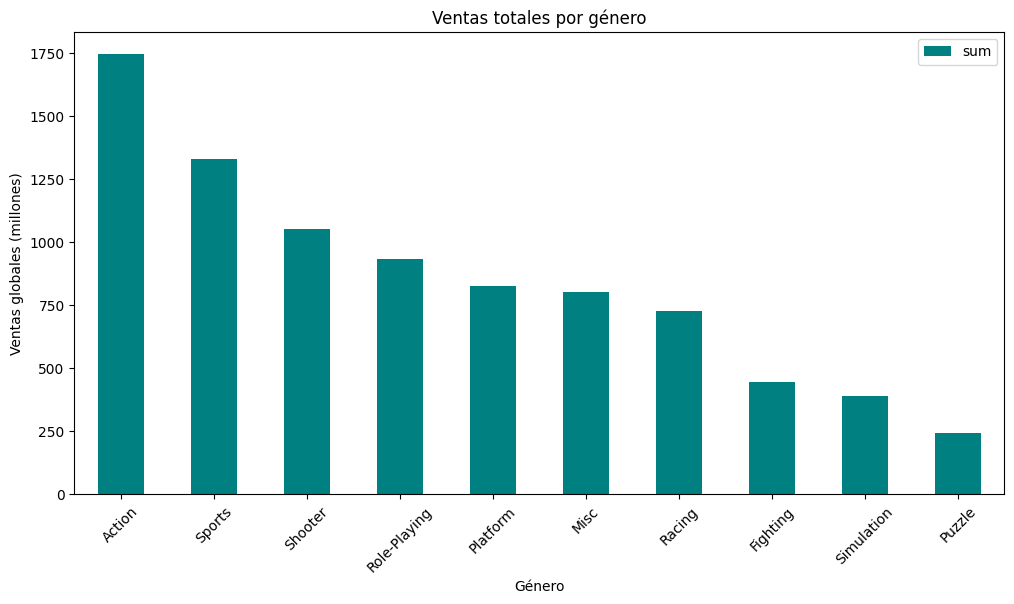

                  sum      mean  median  count
genre                                         
Action        1744.17  0.517711    0.19   3369
Sports        1331.27  0.566980    0.22   2348
Shooter       1052.45  0.795503    0.24   1323
Role-Playing   934.56  0.623872    0.18   1498
Platform       827.77  0.932173    0.27    888
Misc           802.51  0.458577    0.16   1750
Racing         728.67  0.583403    0.19   1249
Fighting       447.53  0.527126    0.21    849
Simulation     389.97  0.446701    0.15    873
Puzzle         242.57  0.418224    0.11    580


In [107]:
genre_stats = games.groupby('genre')['total_sales'].agg(['sum','mean','median','count']).sort_values('sum', ascending=False)
genre_stats.head(10).plot(kind='bar', y='sum', figsize=(12,6), color='teal')
plt.title('Ventas totales por género')
plt.xlabel('Género')
plt.ylabel('Ventas globales (millones)')
plt.xticks(rotation=45)
plt.show()

print(genre_stats.head(10))


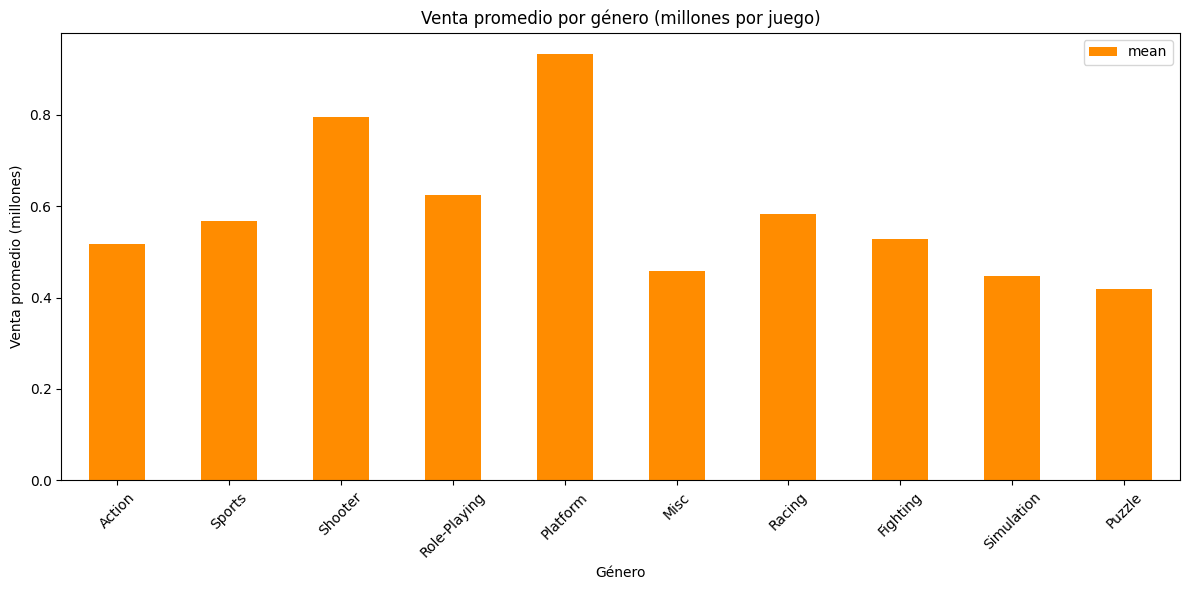

In [108]:
# Graficar venta promedio por género
genre_stats.head(10).plot(kind='bar', y='mean', figsize=(12,6), color='darkorange')
plt.title('Venta promedio por género (millones por juego)')
plt.xlabel('Género')
plt.ylabel('Venta promedio (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Ok con el gráfico, pero la rentabilidad no solo es el total de ventas, sino que también hay que ver la venta promedio por género. Te recomiendo calcular y graficar la venta promedio de cada género.

</div>

In [109]:
print('Observamos que plataform tiene mayor ventas y rentabilidad aunque en se observa que action tiene mayor venta en realidad su media es de 0.5, mientas que de plataform es de 0.93, sus ventas tienen un nimero menor porque tambien cuenta con menos juegos de ese tipo.') 

Observamos que plataform tiene mayor ventas y rentabilidad aunque en se observa que action tiene mayor venta en realidad su media es de 0.5, mientas que de plataform es de 0.93, sus ventas tienen un nimero menor porque tambien cuenta con menos juegos de ese tipo.


In [110]:

regions = ['na_sales','eu_sales','jp_sales']

for region in regions:
    print(f"\nTop 5 plataformas en {region}:")
    print(games.groupby('platform')[region].sum().sort_values(ascending=False).head(5))
    print(f"\nTop 5 géneros en {region}:")
    print(games.groupby('genre')[region].sum().sort_values(ascending=False).head(5))

# Efecto del rating ESRB
for region in regions:
    print(f"\nMedianas por rating para {region}:")
    print(games.groupby('rating')[region].median().dropna().sort_values(ascending=False))




Top 5 plataformas en na_sales:
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 géneros en na_sales:
genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 plataformas en eu_sales:
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 géneros en eu_sales:
genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 plataformas en jp_sales:
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64

Top 5 géneros en jp_sales:
genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64

Medianas por rating para na_sales:
rating
AO      1.260
K-A    

In [111]:
print('''Observamos que las plataformas más populares:
Norte América: X360, PS2, Wii, PS3, DS
Europa: PS2, PS3, X360, Wii, PS
Japón: DS, PS, PS2, SNES, 3DS
las plataformas son similares excepto Japon en el cual la principal es DS''')

Observamos que las plataformas más populares:
Norte América: X360, PS2, Wii, PS3, DS
Europa: PS2, PS3, X360, Wii, PS
Japón: DS, PS, PS2, SNES, 3DS
las plataformas son similares excepto Japon en el cual la principal es DS


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, muy bien con la comparación entre las regiones. Es importante revisar diferentes dimensiones entre cada uno, esto revela puntos importantes de segmentación que podrían ser beneficiosos para un modelo de predicción. Por ejemplo, observamos que Japón es muy diferente respecto a las otras regiones en varios aspectos, tal vez esto justifique diferentes modelos o reglas para esta región.
    
</div>

In [112]:
alpha = 0.05

# H1: Xbox One vs PC
xbox = games[games['platform'].str.contains('XOne', case=False, na=False)]
pc = games[games['platform'].str.contains('pc', case=False, na=False)]

print("\nDetectado xbox:", xbox['platform'].unique() if not xbox.empty else None,
      "pc:", pc['platform'].unique() if not pc.empty else None)

if xbox.empty or pc.empty:
    print("No hay suficientes datos para H1 (Xbox vs PC).")
else:
    t_stat, p_val = st.ttest_ind(xbox['user_score'].dropna(), pc['user_score'].dropna(), equal_var=False)
    print(f"H1 -> t={t_stat}, p={p_val}")
    if p_val < alpha:
        print("Rechazamos H0: las medias son diferentes.")
    else:
        print("No rechazamos H0: no hay diferencia significativa.")


Detectado xbox: ['XOne'] pc: ['PC' 'PCFX']
H1 -> t=-4.653422798410771, p=4.935072360183574e-06
Rechazamos H0: las medias son diferentes.


In [113]:
print('''Realizamos la hipótesis de que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas, nos da como resultado que se rechaza la hipotesis, es decir, si hay una diferencia en la puntuacion de los usuarios

''')


Realizamos la hipótesis de que las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas, nos da como resultado que se rechaza la hipotesis, es decir, si hay una diferencia en la puntuacion de los usuarios




In [114]:
action = games[games['genre']=='Action']['user_score'].dropna()
sports = games[games['genre']=='Sports']['user_score'].dropna()

print("Muestras H2: Action:", len(action), "Sports:", len(sports))
t_stat, p_val = st.ttest_ind(action, sports, equal_var=False)
print("t-stat H2:", t_stat, "p-val H2:", p_val)

if p_val < alpha:
    print("Rechazamos H0: hay diferencia significativa entre Action y Sports.")
else:
    print("No rechazamos H0: no hay evidencia de diferencia en medias entre Action y Sports.")

Muestras H2: Action: 1830 Sports: 1103
t-stat H2: 1.57746791633354 p-val H2: 0.11483818791498286
No rechazamos H0: no hay evidencia de diferencia en medias entre Action y Sports.


In [115]:
print(""" Rechazamos la hipótesis ya que no hay evidencia suficiente para decir que hay diferencia significativa en las calificaciones de los usuarios
""")


 Rechazamos la hipótesis ya que no hay evidencia suficiente para decir que hay diferencia significativa en las calificaciones de los usuarios



<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con los tests, fueron realizados de forma correcta. 

Es importante mencionar que el t-test asume que las dos muestras tienen varianzas iguales Para verificar esa igualdad de varianzas podemos usar el **test de Levene**. Este nos dice si la variabilidad entre los grupos es *estadísticamente diferente*. En futuros notebooks podrías utilizar este test para decidir sobre la igualdad de varianzas. En corto, el flujo sería así

1. Usamos `levene()` para verificar si las varianzas son iguales.
2. Dependiendo del resultado, usamos `ttest_ind()` con el argumento `equal_var`:
   - `equal_var=True` si Levene dice que las varianzas son iguales (p > 0.05).
   - `equal_var=False` si Levene dice que las varianzas son diferentes (p < 0.05).

</div>

Conclusión

Se realizó un análisis de la venta de juegos de 1980 a 2016, así como las plataformas en las cuales se vendieron, se analizó también la influencia de la calificación de usuarios y críticos en donde se observó que la opinión de los críticos tiene mayor correlación en cuanto a ventas que los usuarios, con una correlación de 0.39, observamos que la plataforma con mayores ventas es PS2 con 1255.77 millones de ventas seguido de X360 con 971.42 millones de ventas; observamos que el género de acción tiene mayores ventas, 1744.17 millones, sin embargo esto también se debe a que tiene mayores juegos y en realidad el género con mayor rentabilidad es platform, se realizaron dos pruebas de hipótesis, la primera en donde se afirma que la calificación promedio de los usuarios para Xbox one y PC son las mismas, se rechazó la hipótesis con p=4.93 la segunda hipótesis afirma que las calificaciones de los usuarios para los géneros de acción y deportes son diferentes en donde se rechaza la hipótesis ya que no hay evidencia de que sean diferentes con p=0.11
Como conclusión podemos recomendar realizar juegos del género platform ya que es la que tiene mayor rentabilidad con 827.77 millones de ventas a pesar de tener menos de mil juegos



<div class="alert alert-block alert-danger">
<b>Comentario de Revisor              </b><a class="tocSkip"></a>

Completa esta parte con una conclusión del proyecto: Señala el trabajo más importante realizado sobre la data y las principales conclusiones, idealmente mencionando métricas importantes.



</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor     v2       </b> <a class="tocSkip"></a>

Muy bien con estas conclusiones. Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos. Haces muy bien al incluir las métricas más importantes, tus afirmaciones se ven apoyadas en algo objetivo.   

    
</div>